In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- SUA ESTRUTURA DE DIRETÓRIOS E CAPTURA ---
ROOT_DIR = "drive/MyDrive/heatmaps"  # Ajuste para a sua pasta raiz
patient_dict = {"Healthy": {}, "Sick": {}}
classes = ["Healthy", "Sick"]

for classe in classes:
    class_path = os.path.join(ROOT_DIR, classe)
    label = 0 if classe == "Healthy" else 1

    if not os.path.exists(class_path):
        continue

    for paciente in os.listdir(class_path):
        paciente_path = os.path.join(class_path, paciente)
        if not os.path.isdir(paciente_path):
            continue

        patient_images = []

        for visita in os.listdir(paciente_path):
            visita_path = os.path.join(paciente_path, visita, "images", "thermography")

            for modo in ["static", "dynamic"]:
                modo_path = os.path.join(visita_path, modo)
                if not os.path.exists(modo_path):
                    continue

                for file in os.listdir(modo_path):
                    if not file.lower().endswith(".jpg"):
                        continue

                    nome = os.path.splitext(file)[0]
                    partes = nome.split(".")

                    if len(partes) < 5:
                        continue

                    codigo = f"{partes[1]}.{partes[2]}"
                    if codigo != "1.1":
                        continue

                    image_path = os.path.join(modo_path, file)
                    patient_images.append((image_path, label))

        patient_dict[classe][paciente] = patient_images


Processamento concluído. Imagens analisadas -> Healthy: 3454 | Sick: 790


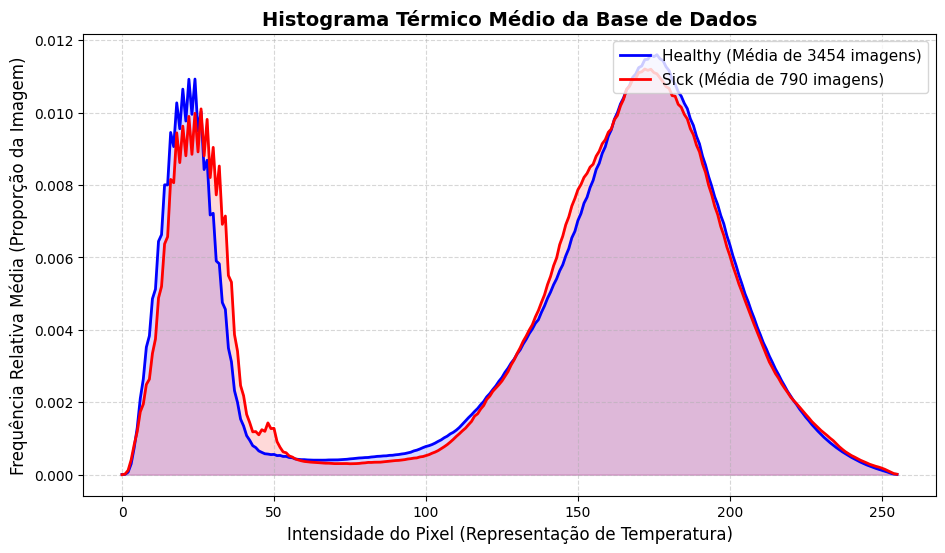

In [ ]:
# --- ETAPA DE MINERAÇÃO: CÁLCULO DO HISTOGRAMA MÉDIO ---

# Dicionários para acumular os histogramas e contar as imagens
hist_acumulado = {"Healthy": np.zeros(256), "Sick": np.zeros(256)}
total_imagens = {"Healthy": 0, "Sick": 0}

# Iterar pela estrutura populada para ler as imagens fisicamente
for classe in classes:
    for paciente, lista_imagens in patient_dict[classe].items():
        for image_path, label in lista_imagens:

            # Ler a imagem em escala de cinza (essencial para intensidade térmica direta)
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                # Calcula o histograma da imagem atual (valores de 0 a 255)
                hist = cv2.calcHist([img], [0], None, [256], [0, 256])

                # Normaliza o histograma individual pela quantidade de pixels da própria imagem.
                hist /= img.size

                # Acumula no grupo correspondente
                hist_acumulado[classe] += hist.flatten()
                total_imagens[classe] += 1

# Calcular a média real dividindo o acumulado pelo número de imagens processadas
hist_medio_healthy = hist_acumulado["Healthy"] / total_imagens["Healthy"] if total_imagens["Healthy"] > 0 else np.zeros(256)
hist_medio_sick = hist_acumulado["Sick"] / total_imagens["Sick"] if total_imagens["Sick"] > 0 else np.zeros(256)

print(f"Processamento concluído. Imagens analisadas -> Healthy: {total_imagens['Healthy']} | Sick: {total_imagens['Sick']}")


# --- PLOTAGEM DO GRÁFICO ---
plt.figure(figsize=(11, 6))

# Eixo X representa os tons de cinza (0 = Frio, 255 = Quente)
tons_de_cinza = np.arange(256)

# Plotar curva média Healthy
plt.plot(tons_de_cinza, hist_medio_healthy, color='blue', label=f'Healthy (Média de {total_imagens["Healthy"]} imagens)', linewidth=2)
plt.fill_between(tons_de_cinza, hist_medio_healthy, color='blue', alpha=0.15)

# Plotar curva média Sick
plt.plot(tons_de_cinza, hist_medio_sick, color='red', label=f'Sick (Média de {total_imagens["Sick"]} imagens)', linewidth=2)
plt.fill_between(tons_de_cinza, hist_medio_sick, color='red', alpha=0.15)

plt.title('Histograma Térmico Médio da Base de Dados', fontsize=14, fontweight='bold')
plt.xlabel('Intensidade do Pixel (Representação de Temperatura)', fontsize=12)
plt.ylabel('Frequência Relativa Média (Proporção da Imagem)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Texturas

Extraindo recursos de textura (GLCM)...
Extração concluída! Total de registros: 4244


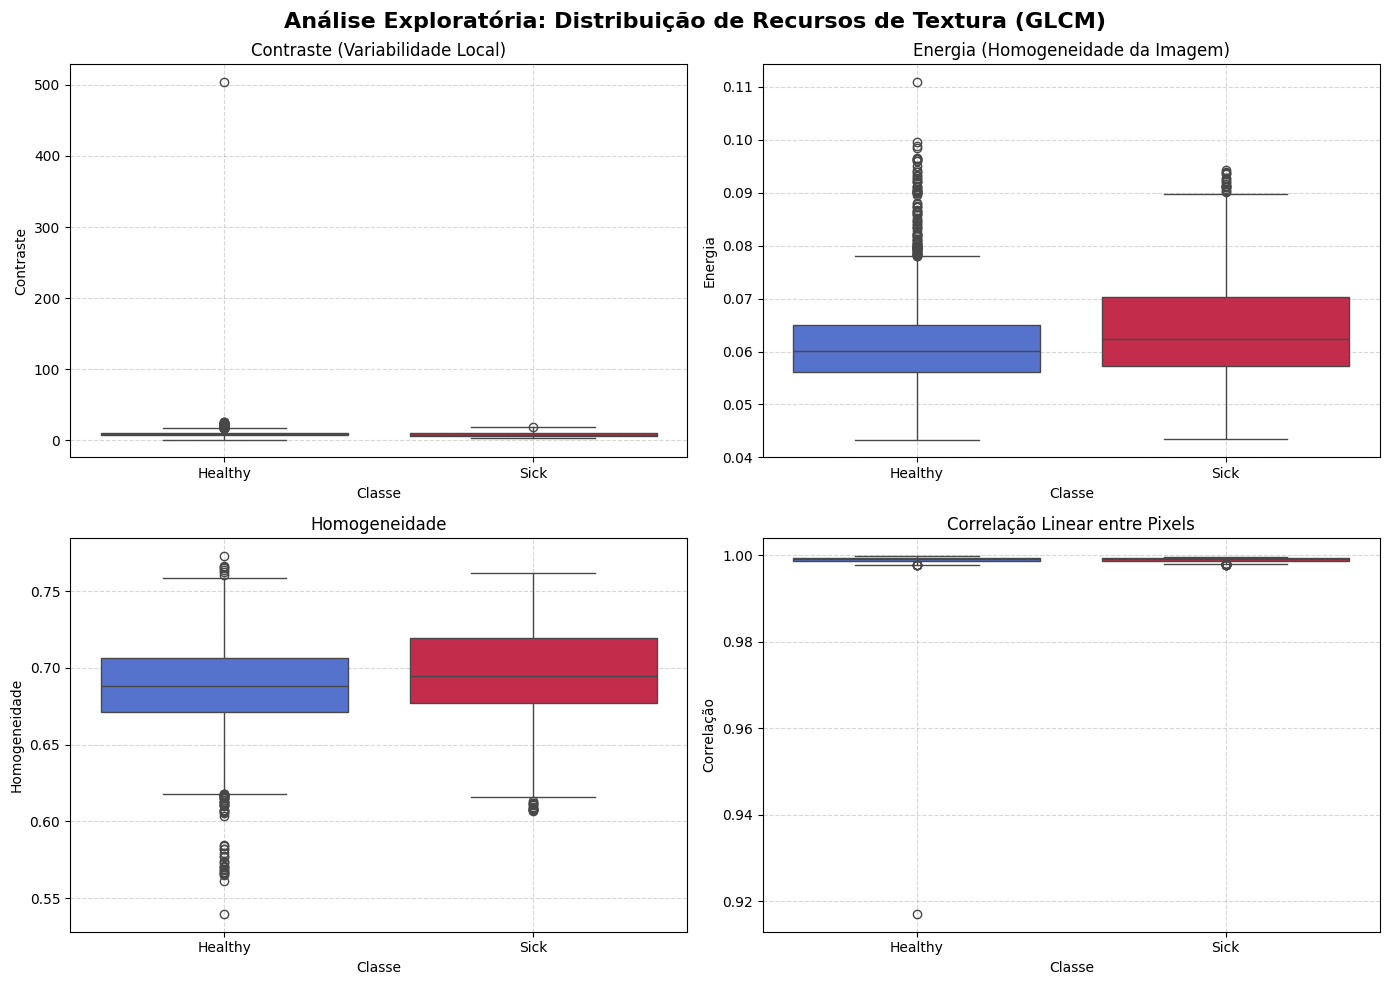

In [ ]:
import pandas as pd
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops

# 1. Criar uma lista para armazenar os dados de textura de cada imagem
textura_data = []

print("Extraindo recursos de textura (GLCM)...")

for classe in classes:
    for paciente, lista_imagens in patient_dict[classe].items():
        for image_path, label in lista_imagens:

            # Ler a imagem em escala de cinza
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                # Calcular a GLCM
                glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

                # Extrair as propriedades estatísticas da matriz
                contraste = graycoprops(glcm, 'contrast')[0, 0]
                energia = graycoprops(glcm, 'energy')[0, 0]
                homogeneidade = graycoprops(glcm, 'homogeneity')[0, 0]
                correlacao = graycoprops(glcm, 'correlation')[0, 0]

                # Armazenar no dicionário com o rótulo da classe
                textura_data.append({
                    "Classe": classe,
                    "Contraste": contraste,
                    "Energia": energia,
                    "Homogeneidade": homogeneidade,
                    "Correlação": correlacao
                })

# Convertendo para um DataFrame do Pandas para facilitar a plotagem
df_textura = pd.DataFrame(textura_data)
print(f"Extração concluída! Total de registros: {len(df_textura)}")

# --- 2. PLOTAGEM DOS BOXPLOTS ---
# Criando uma figura com subplots para analisar as métricas lado a lado
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise Exploratória: Distribuição de Recursos de Textura (GLCM)', fontsize=16, fontweight='bold')

# Cores personalizadas para combinar com o padrão anterior (Healthy = Azul, Sick = Vermelho)
cores = {"Healthy": "royalblue", "Sick": "crimson"}

# Boxplot 1: Contraste
sns.boxplot(ax=axes[0, 0], data=df_textura, x="Classe", y="Contraste", palette=cores, hue="Classe", legend=False)
axes[0, 0].set_title('Contraste (Variabilidade Local)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Boxplot 2: Energia
sns.boxplot(ax=axes[0, 1], data=df_textura, x="Classe", y="Energia", palette=cores, hue="Classe", legend=False)
axes[0, 1].set_title('Energia (Homogeneidade da Imagem)')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Boxplot 3: Homogeneidade
sns.boxplot(ax=axes[1, 0], data=df_textura, x="Classe", y="Homogeneidade", palette=cores, hue="Classe", legend=False)
axes[1, 0].set_title('Homogeneidade')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Boxplot 4: Correlação
sns.boxplot(ax=axes[1, 1], data=df_textura, x="Classe", y="Correlação", palette=cores, hue="Classe", legend=False)
axes[1, 1].set_title('Correlação Linear entre Pixels')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Aqui está a interpretação científica e prática de cada quadrante para você usar no seu artigo (Item 4):
1. Contraste (Variabilidade Local)O que o gráfico mostra: A imensa maioria dos dados de ambas as classes está esmagada bem próxima de zero. O grupo Healthy possui um outlier extremo próximo de 500 (provavelmente uma imagem com ruído, borda muito demarcada ou artefato técnico que vale a pena investigar).Interpretação: O contraste mede a disparidade de intensidade entre pixels vizinhos. Como os valores são baixos para ambos, isso prova que as imagens médicas térmicas possuem transições de temperatura majoritariamente suaves (gradientes contínuos), sem mudanças bruscas de "pixel preto colado em pixel branco".
2. Energia (Homogeneidade Global)O que o gráfico mostra: A mediana do grupo Sick (linha central dentro da caixa vermelha) está ligeiramente mais alta do que a do grupo Healthy (caixa azul).Interpretação: A energia mede a uniformidade dos tons de cinza. Uma energia ligeiramente maior no grupo Sick indica que as imagens dos pacientes doentes tendem a ser um pouco mais homogêneas/padronizadas em certas áreas térmicas (por exemplo, grandes blocos de calor devido a uma inflamação generalizada), enquanto o grupo Healthy tem uma distribuição de temperatura um pouco mais variada e espalhada pelo corpo.Nota técnica: Observe a enorme quantidade de outliers (as bolinhas) acima da caixa do Healthy. Isso mostra que o grupo saudável tem muitas subcondições ou variações anatômicas normais que geram imagens muito uniformes.
3. HomogeneidadeO que o gráfico mostra: Confirmando o que vimos na Energia, a caixa Sick está deslocada para cima em comparação à Healthy.Interpretação: A Homogeneidade avalia a proximidade da distribuição dos elementos na GLCM em relação à diagonal da matriz. O fato de o grupo Sick ser mais homogêneo reforça a hipótese de que a patologia cria "manchas" térmicas contínuas e estáveis. O grupo saudável apresenta maior variabilidade para baixo (caixa mais comprida e muitos outliers inferiores), significando que corpos saudáveis mudam mais de dinâmica térmica local dependendo do paciente.
4. Correlação Linear entre PixelsO que o gráfico mostra: Ambas as classes estão praticamente coladas no valor $1.00$ (correlação quase perfeita), com exceção de um outlier gritante no grupo Healthy perto de $0.92$.Interpretação: Isso é perfeitamente normal em imagens médicas e térmicas. Significa que se um pixel está a uma temperatura X, o pixel imediatamente ao lado dele está a uma temperatura muitíssimo próxima de X. Não há ruído aleatório do tipo "sal e pimenta".
💡 Como justificar o uso do ViT com base nesses gráficos?Para a seção 3.c (Justificativa dos algoritmos), você pode usar esse resultado da seguinte forma:"A análise exploratória via GLCM demonstrou que as classes Healthy e Sick apresentam alto grau de semelhança estatística global e forte correlação linear local ($>0.99$). Contudo, pequenas distinções na Homogeneidade e Energia indicam que a patologia altera sutilmente a organização espacial dos tecidos térmicos. Dado que as diferenças são sutis e dependem do contexto de blocos de imagem (texturas mais ou menos homogêneas), modelos de Redes Convolucionais tradicionais (CNNs) focados apenas em bordas locais podem falhar. Isso justifica a escolha do Vision Transformer (ViT), cujo mecanismo de auto-atenção consegue capturar as dependências de longo alcance e os padrões de textura globais (patches) necessários para separar classes com alta sobreposição estatística."

Extraindo Histogramas e GLCM para o t-SNE...
Executando o t-SNE (reduzindo para 2D)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


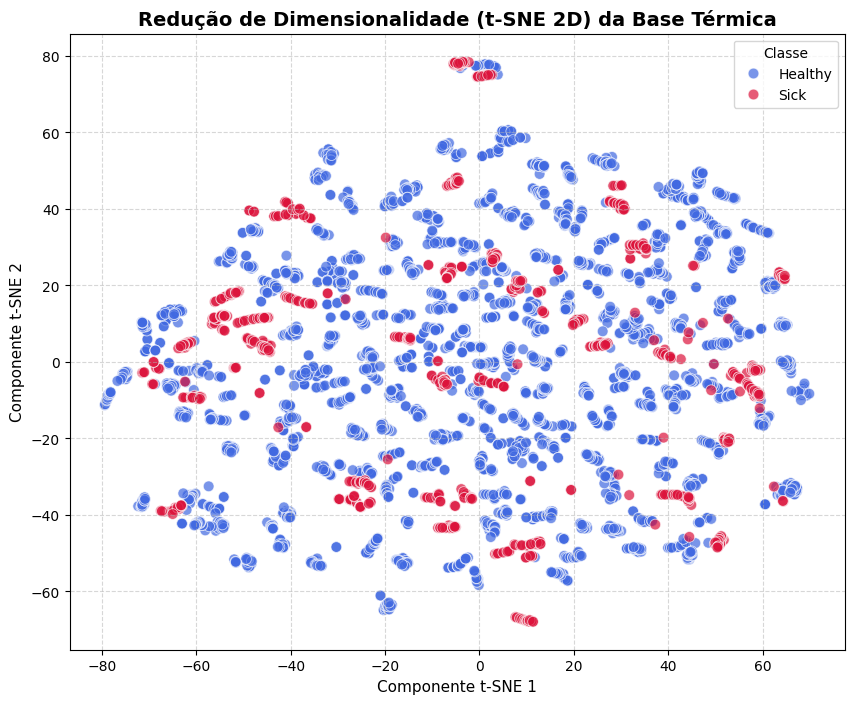

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from skimage.feature import graycomatrix, graycoprops

# 1. Listas para armazenar os vetores de características e os rótulos
caracteristicas_completas = []
rotulos = []

print("Extraindo Histogramas e GLCM para o t-SNE...")

for classe in classes:
    for paciente, lista_imagens in patient_dict[classe].items():
        for image_path, label in lista_imagens:

            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                # --- Característica 1: Histograma Normalizado (256 valores) ---
                hist = cv2.calcHist([img], [0], None, [256], [0, 256])
                hist /= img.size  # Normaliza pelo tamanho
                hist_flat = hist.flatten()

                # --- Característica 2: Métricas GLCM (4 valores) ---
                glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
                contraste = graycoprops(glcm, 'contrast')[0, 0]
                energia = graycoprops(glcm, 'energy')[0, 0]
                homogeneidade = graycoprops(glcm, 'homogeneity')[0, 0]
                correlacao = graycoprops(glcm, 'correlation')[0, 0]
                glcm_features = np.array([contraste, energia, homogeneidade, correlacao])

                # Concatenar Histograma + GLCM para formar o vetor completo da imagem (260 dimensões)
                vetor_imagem = np.concatenate((hist_flat, glcm_features))

                caracteristicas_completas.append(vetor_imagem)
                rotulos.append(classe)

# Converter para Array NumPy
X = np.array(caracteristicas_completas)
y = np.array(rotulos)

# --- 2. PADRONIZAÇÃO DOS DADOS (Crucial para o t-SNE) ---
# Como o histograma varia entre 0 e 1 e o contraste pode ir até 500, precisamos normalizar a escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. APLICAÇÃO DO t-SNE ---
print("Executando o t-SNE (reduzindo para 2D)...")
# perplexity: define o balanço entre focar na estrutura local ou global (valores comuns entre 5 e 50)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Criar um DataFrame para facilitar a plotagem com Seaborn
df_tsne = pd.DataFrame(X_tsne, columns=['Componente t-SNE 1', 'Componente t-SNE 2'])
df_tsne['Classe'] = y

# --- 4. PLOTAGEM DO SCATTER PLOT ---
plt.figure(figsize=(10, 8))
cores = {"Healthy": "royalblue", "Sick": "crimson"}

sns.scatterplot(
    data=df_tsne,
    x='Componente t-SNE 1',
    y='Componente t-SNE 2',
    hue='Classe',
    palette=cores,
    alpha=0.7,
    s=60,  # Tamanho dos pontos
    edgecolor='w'
)

plt.title('Redução de Dimensionalidade (t-SNE 2D) da Base Térmica', fontsize=14, fontweight='bold')
plt.xlabel('Componente t-SNE 1', fontsize=11)
plt.ylabel('Componente t-SNE 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Classe', loc='best')

plt.show()

🔍 O que esse gráfico está dizendo sobre seus dados?
Problema Não-Linearmente Separável: As características globais tradicionais (estatística de histograma e textura macro da GLCM) não são suficientes para separar quem é saudável de quem está doente. Se você aplicasse uma Regressão Logística, uma Árvore de Decisão ou um SVM linear aqui, a acurácia seria péssima (perto de 50%, o famoso cara ou coroa).

Micro-padrões Locais Importam: O t-SNE tentou agrupar as imagens por similaridade estatística bruta. O fato de estarem misturadas indica que um paciente Sick e um Healthy compartilham quase a mesma distribuição de temperatura global e o mesmo nível de ruído/textura na imagem como um todo. A diferença real deve estar em detalhes muito localizados ou no contexto geométrico (ex: o formato ou a assimetria de uma mancha térmica específica).

Na Seção de Análise Exploratória (Item 2):
"A fim de avaliar a separabilidade linear do dataset antes da etapa de classificação, aplicou-se o algoritmo t-SNE para redução de dimensionalidade (2D) combinando os vetores de histograma térmico e descritores texturais GLCM. O mapeamento revelou uma distribuição dispersa e com forte sobreposição (interpenetração) entre as classes Healthy e Sick. Esse comportamento evidencia a alta complexidade do problema e demonstra que métricas estatísticas globais isoladas são incapazes de discriminar as patologias de forma linear."

Na Seção de Justificativa do Modelo (Item 3.c):
"A forte sobreposição observada na análise por t-SNE justifica diretamente a rejeição de classificadores estatísticos tradicionais ou shallow learning. Para mitigar a similaridade macro das imagens, faz-se necessária uma abordagem capaz de fatiar a imagem e correlacionar micro-estruturas texturais de maneira não-linear. Desse modo, justifica-se o uso do Vision Transformer (ViT): seu mecanismo de Self-Attention (Auto-Atenção) foca a computação nos patches (blocos) semanticamente relevantes e aprende as relações de longo alcance que os métodos de mineração clássicos não conseguiram capturar."

In [ ]:
total_pacientes_healthy = len(patient_dict["Healthy"])
total_pacientes_sick = len(patient_dict["Sick"])

total_imagens_healthy = sum(len(fotos) for fotos in patient_dict["Healthy"].values())
total_imagens_sick = sum(len(fotos) for fotos in patient_dict["Sick"].values())

print("="*45)
print("   ESTATÍSTICAS DA BASE DE DADOS (ITEM 2.a)   ")
print("="*45)
print(f"Classe HEALTHY:")
print(f"  - Total de Pacientes Únicos: {total_pacientes_healthy}")
print(f"  - Total de Imagens Térmicas: {total_imagens_healthy}")
print(f"  - Média de imagens por paciente: {total_imagens_healthy/total_pacientes_healthy:.1f}" if total_pacientes_healthy > 0 else 0)
print("-"*45)
print(f"Classe SICK:")
print(f"  - Total de Pacientes Únicos: {total_pacientes_sick}")
print(f"  - Total de Imagens Térmicas: {total_imagens_sick}")
print(f"  - Média de imagens por paciente: {total_imagens_sick/total_pacientes_sick:.1f}" if total_pacientes_sick > 0 else 0)
print("="*45)
print(f"TOTAL GERAL: {total_pacientes_healthy + total_pacientes_sick} pacientes | {total_imagens_healthy + total_imagens_sick} imagens")
print("="*45)

   ESTATÍSTICAS DA BASE DE DADOS (ITEM 2.a)   
Classe HEALTHY:
  - Total de Pacientes Únicos: 192
  - Total de Imagens Térmicas: 3454
  - Média de imagens por paciente: 18.0
---------------------------------------------
Classe SICK:
  - Total de Pacientes Únicos: 46
  - Total de Imagens Térmicas: 790
  - Média de imagens por paciente: 17.2
TOTAL GERAL: 238 pacientes | 4244 imagens


In [ ]:
import torch
from torchvision import transforms

IMG_SIZE = 224

# Medias e desvios padrão oficiais do ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([

    transforms.ToTensor(),

    transforms.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.9, 1.0), ratio=(0.95, 1.05)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 2. PIPELINE DE VALIDAÇÃO E TESTE
valid_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Pipelines de transformação criados com sucesso!")

Pipelines de transformação criados com sucesso!


In [ ]:
from PIL import Image

todas_imagens = []
todos_labels = []
todos_pacientes = []

for classe in ["Healthy", "Sick"]:
    for paciente, lista_imagens in patient_dict[classe].items():
        for img_path, label in lista_imagens:
            todas_imagens.append((img_path, label))
            todos_labels.append(label)
            todos_pacientes.append(paciente)

X_paths = np.array(todas_imagens)
y_labels = np.array(todos_labels)
groups_pacientes = np.array(todos_pacientes)

# A nova classe de Dataset adaptada para o K-Fold
class KFoldTermografiaDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

master_train_dataset = KFoldTermografiaDataset(todas_imagens, transform=train_transforms)
master_val_dataset = KFoldTermografiaDataset(todas_imagens, transform=valid_transforms)

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, Subset
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import torch.optim as optim
import timm
import copy

todos_os_labels_gerais = []
todas_as_preds_gerais = []

sgkf = StratifiedGroupKFold(n_splits=5)
epochs_por_fold = 10
historico_dos_folds = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Iniciando Validação Cruzada (5-Fold)...")

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_paths, y_labels, groups_pacientes)):
    print(f"\n======== TREINANDO O FOLD {fold+1}/5 ========")

    train_subset = Subset(master_train_dataset, train_idx)
    val_subset = Subset(master_val_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

    labels_treino_fold = y_labels[train_idx]
    class_weights = compute_class_weight('balanced', classes=np.unique(labels_treino_fold), y=labels_treino_fold)
    pesos_classes = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=pesos_classes)

    model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=2, drop_rate=0.3)
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.1)

    fold_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_acc = 0
    best_preds = None
    best_labels = None
    best_weights = None

    # Épocas
    for epoch in range(epochs_por_fold):

        preds_epoch = []
        labels_epoch = []

        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()


        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

                preds_epoch.extend(predicted.cpu().numpy())
                labels_epoch.extend(labels.cpu().numpy())
                # todas_as_preds_gerais.extend(predicted.cpu().numpy())
                # todos_os_labels_gerais.extend(labels.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss = val_loss / val_total
        train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        if val_acc > best_acc:
          best_acc = val_acc
          best_weights = copy.deepcopy(model.state_dict())
          best_preds = preds_epoch.copy()
          best_labels = labels_epoch.copy()

        fold_history['train_loss'].append(train_loss)
        fold_history['val_loss'].append(val_loss)
        fold_history['train_acc'].append(train_acc)
        fold_history['val_acc'].append(val_acc)

    todas_as_preds_gerais.extend(best_preds)
    todos_os_labels_gerais.extend(best_labels)

    print(f"Fold {fold+1} Concluído! Melhor Acc Val: {max(fold_history['val_acc'])*100:.1f}%")
    historico_dos_folds.append(fold_history)
    print(f"Labels: {len(todos_os_labels_gerais)}")
    print(f"Preds: {len(todas_as_preds_gerais)}")

Iniciando Validação Cruzada (5-Fold)...

======== TREINANDO O FOLD 1/5 ========


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Fold 1 Concluído! Melhor Acc Val: 88.9%
Labels: 858
Preds: 858

======== TREINANDO O FOLD 2/5 ========
Fold 2 Concluído! Melhor Acc Val: 90.0%
Labels: 1716
Preds: 1716

======== TREINANDO O FOLD 3/5 ========
Fold 3 Concluído! Melhor Acc Val: 84.0%
Labels: 2554
Preds: 2554

======== TREINANDO O FOLD 4/5 ========
Fold 4 Concluído! Melhor Acc Val: 85.3%
Labels: 3406
Preds: 3406

======== TREINANDO O FOLD 5/5 ========
Fold 5 Concluído! Melhor Acc Val: 90.5%
Labels: 4244
Preds: 4244



       RELATORIO DE CLASSIFICAÇÃO       
              precision    recall  f1-score   support

     Healthy       0.91      0.94      0.93      3454
        Sick       0.70      0.59      0.64       790

    accuracy                           0.88      4244
   macro avg       0.81      0.77      0.78      4244
weighted avg       0.87      0.88      0.87      4244



<Axes: >

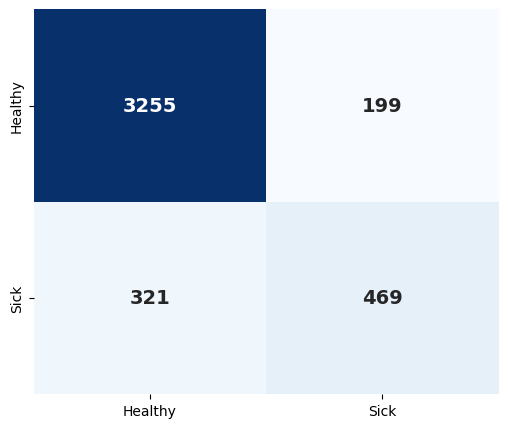

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("       RELATORIO DE CLASSIFICAÇÃO       ")
print("="*60)
print(classification_report(todos_os_labels_gerais, todas_as_preds_gerais, target_names=["Healthy", "Sick"]))
print("="*60)


plt.figure(figsize=(6, 5))
cm_consolidada = confusion_matrix(todos_os_labels_gerais, todas_as_preds_gerais)

sns.heatmap(cm_consolidada, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Healthy", "Sick"], yticklabels=["Healthy", "Sick"],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})


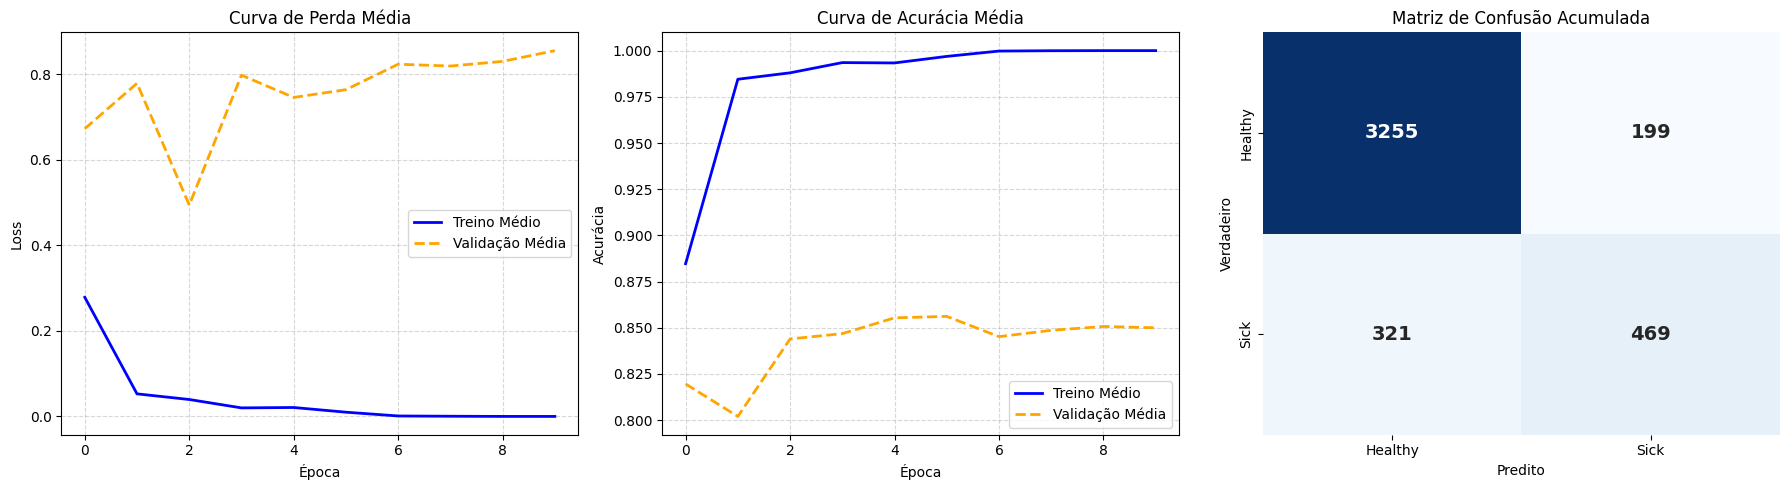

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Extrair e tirar a média das curvas de Loss e Acc de todos os 5 folds
num_epochs = len(historico_dos_folds[0]['train_loss'])

media_train_loss = np.mean([f['train_loss'] for f in historico_dos_folds], axis=0)
media_val_loss = np.mean([f['val_loss'] for f in historico_dos_folds], axis=0)
media_train_acc = np.mean([f['train_acc'] for f in historico_dos_folds], axis=0)
media_val_acc = np.mean([f['val_acc'] for f in historico_dos_folds], axis=0)

# 2. Configurar a figura tripla (igual à sua ideia original)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(media_train_loss, label='Treino Médio', color='blue', linewidth=2)
axes[0].plot(media_val_loss, label='Validação Média', color='orange', linewidth=2, linestyle='--')
axes[0].set_title('Curva de Perda Média')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Acurácia
axes[1].plot(media_train_acc, label='Treino Médio', color='blue', linewidth=2)
axes[1].plot(media_val_acc, label='Validação Média', color='orange', linewidth=2, linestyle='--')
axes[1].set_title('Curva de Acurácia Média')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# Matriz de Confusão
cm_consolidada = confusion_matrix(todos_os_labels_gerais, todas_as_preds_gerais)
sns.heatmap(cm_consolidada, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=["Healthy", "Sick"], yticklabels=["Healthy", "Sick"],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[2].set_title('Matriz de Confusão Acumulada')
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Verdadeiro')

plt.tight_layout()
plt.show()